# Turn-of-the-Month 📅
### Do almost all the market's gains really land in the ~4 days around month-end?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Almost all the gains?: Busted](https://img.shields.io/badge/Almost_all_the_gains%3F-Busted-8b949e?style=flat-square)

An old desk saying: *the market makes almost all its money in a tiny window straddling the turn of the month — the last day of the old month and the first three of the new one — so just own stocks then and skip the rest.* We take it literally and ask the two questions that matter: is that window **really** where the money is (**partly** — about a third of the return in a fifth of the days), and could you **get richer** owning only those days (**no** — far poorer).

> 📓 **This is the plain-language layer.** The statistics, the long-history sample and the per-day-invested maths are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (turn_of_the_month/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from turn_of_the_month import data, strategy

AS_OF = "2026-06-12"
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
wc = strategy.window_contrast(close, last=1, first=3)
pos = strategy.tom_position(close.index, last=1, first=3)
timer = strategy.backtest(close, pos, cost_bps=5.0)
bh = strategy.buy_and_hold(close)
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"TOM mean {wc['tom_mean_bps']:+.2f} bps/day  rest {wc['rest_mean_bps']:+.2f} bps/day  diff {wc['diff_bps']:+.2f}  HAC t {wc['t_diff']:+.2f}")
print(f"window = {wc['frac_tom_days']*100:.1f}% of days, earns {wc['share_of_total_logret']*100:.1f}% of total return")
print(f"timer  CAGR {timer['cagr']*100:.2f}%  Sharpe {timer['sharpe']:.3f}  Sharpe(inv) {timer['sharpe_invested']:.3f}  maxDD {timer['max_dd']*100:.1f}%")
print(f"B&H    CAGR {bh['cagr']*100:.2f}%  Sharpe {bh['sharpe']:.3f}  maxDD {bh['max_dd']*100:.1f}%")


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=eb1569cc9e97
TOM mean +7.68 bps/day  rest +4.07 bps/day  diff +3.61  HAC t +1.17
window = 19.1% of days, earns 32.9% of total return
timer  CAGR 2.20%  Sharpe 0.315  Sharpe(inv) 0.895  maxDD -19.3%
B&H    CAGR 10.82%  Sharpe 0.646  maxDD -55.2%


## The answer first 🎯

| Question | Answer |
|---|---|
| Are the gains concentrated around the turn? | **Partly** — the 19% of days in the window earn **33%** of the total return (~1.7x their share). |
| Is it *almost all* the gains, as the saying goes? | **No** — the other ~80% of days still earn most of the return. |
| Could you get richer owning only the window? | **No** — a TOM-only timer makes **2.2%/yr** vs **10.82%/yr** for just holding — about **9 points/yr less**. |

## 1 · The claim

*"Almost all of the market's gains happen in a narrow window around the turn of the month — the last trading day plus the first three of the next. Be invested only then and you capture the market with a fraction of the risk."* It traces back to real academic papers (Ariel 1987; Lakonishok & Smidt 1988), which is what makes it worth a fair test.

## 2 · So what?

If true, it would be a free lunch: the same upside for a quarter of the time exposed to the market, dodging four-fifths of the risk. Every saver should run it. The stakes are exactly that big — so it deserves a literal, honest test.

## 3 · How would we even know?

The window is set purely by the **calendar** — the last trading day of a month and the first three of the next — so it's knowable in advance and there's **no guessing and no peeking** (a calendar rule isn't a forecast). We measure how much of the total return lands inside it, then run a strategy that owns SPY only during the window (cash, earning 0%, otherwise; 5 bps a switch) against simply holding.

## 4 · The teardown — let's actually look

First: split the market's growth into the part earned **inside** the window and the part earned the **rest** of the month.

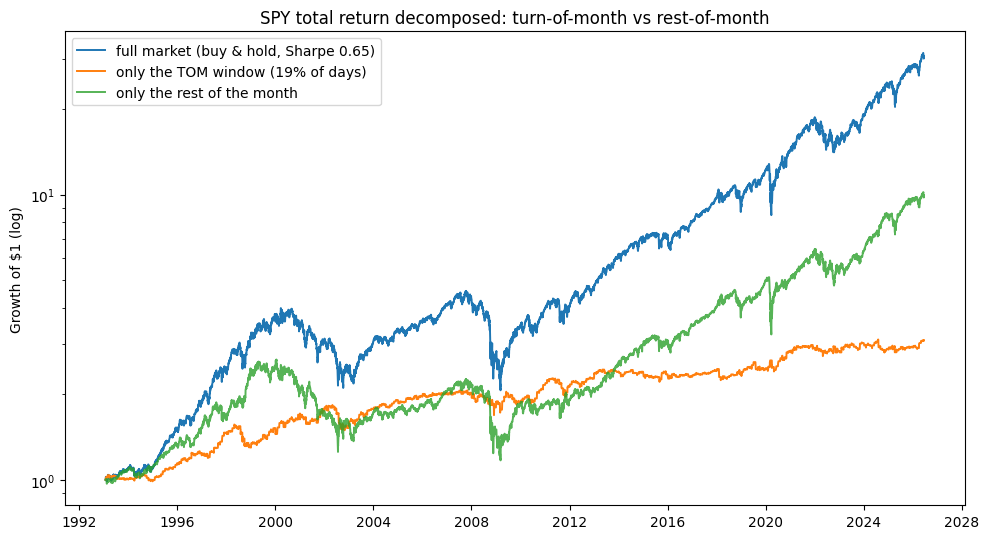

TOM window earns 32.9% of the total cumulative return, in 19.1% of days


In [2]:
# Cumulative return split: what the TOM window contributes vs the rest of the month.
ret = close.pct_change().fillna(0.0)
mask = strategy.tom_mask(ret.index, 1, 3).reindex(ret.index).fillna(False).to_numpy()
tom_only = pd.Series(np.where(mask, ret.to_numpy(), 0.0), index=ret.index)
rest_only = pd.Series(np.where(~mask, ret.to_numpy(), 0.0), index=ret.index)
fig, ax = plt.subplots(figsize=(10,5.5))
ax.plot((1+ret).cumprod(), label=f"full market (buy & hold, Sharpe {bh['sharpe']:.2f})", lw=1.4)
ax.plot((1+tom_only).cumprod(), label=f"only the TOM window ({wc['frac_tom_days']*100:.0f}% of days)", lw=1.4)
ax.plot((1+rest_only).cumprod(), label='only the rest of the month', lw=1.4, alpha=.8)
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)'); ax.legend()
ax.set_title('SPY total return decomposed: turn-of-month vs rest-of-month'); plt.tight_layout(); plt.show()
print(f"TOM window earns {wc['share_of_total_logret']*100:.1f}% of the total cumulative return, in {wc['frac_tom_days']*100:.1f}% of days")

The TOM window pulls **well above its weight** — 33% of the return from 19% of the days — but the *rest of the month* line still climbs a long way. This is real concentration, not *"almost all the gains."*

Now the same thing as a bar chart: average daily return by where the day sits relative to month-end. The orange bars are the `[-1, +3]` window.

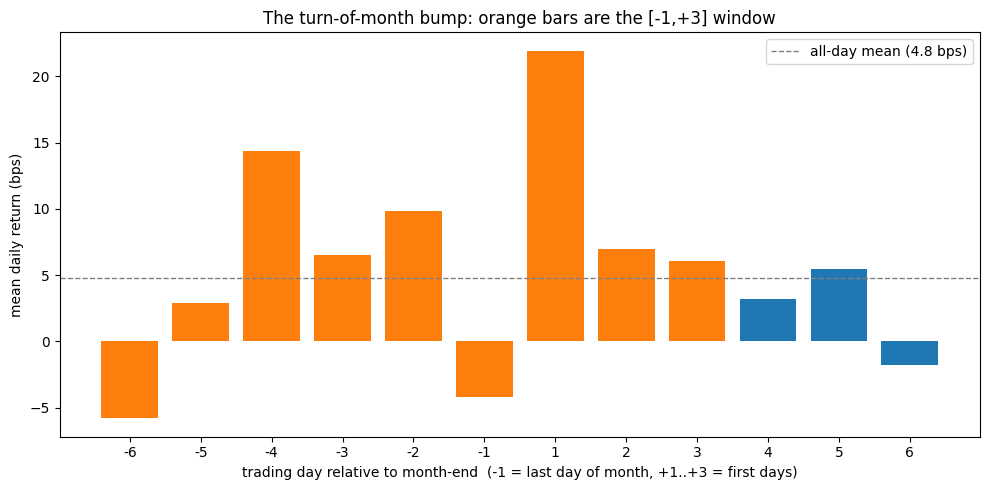

In [3]:
# Mean daily return by signed trading-day-of-month, centred on the turn.
ret = close.pct_change().dropna()
sd = strategy.signed_trading_day(ret.index, around=6).reindex(ret.index)
by_day = (ret.groupby(sd).mean() * 1e4).sort_index()
colors = ['C1' if (d <= -1 or 1 <= d <= 3) else 'C0' for d in by_day.index]
fig, ax = plt.subplots(figsize=(10,5))
ax.bar([str(int(d)) for d in by_day.index], by_day.values, color=colors)
ax.axhline(ret.mean()*1e4, color='grey', ls='--', lw=1, label=f'all-day mean ({ret.mean()*1e4:.1f} bps)')
ax.set_xlabel('trading day relative to month-end  (-1 = last day of month, +1..+3 = first days)')
ax.set_ylabel('mean daily return (bps)'); ax.legend()
ax.set_title('The turn-of-month bump: orange bars are the [-1,+3] window'); plt.tight_layout(); plt.show()

The last day of the month and the first one or two of the next clearly punch above the grey all-day average. The effect is **real** — but look at the size: a few extra basis points a day, not a different universe.

So does owning *only* the window beat just holding? Here are the two strategies head to head.

In [4]:
tbl = pd.DataFrame({
  'CAGR %':  [timer['cagr']*100, bh['cagr']*100],
  'Vol %':   [timer['vol']*100, bh['vol']*100],
  'Sharpe':  [timer['sharpe'], bh['sharpe']],
  'MaxDD %': [timer['max_dd']*100, bh['max_dd']*100],
  'Days invested %': [timer['time_in_market']*100, bh['time_in_market']*100],
}, index=['TOM-only timer', 'Buy & hold']).round(2)
print(tbl)
print(f"\nThe timer trails buy-and-hold by {(bh['cagr']-timer['cagr'])*100:.1f} points a year.")

                CAGR %  Vol %  Sharpe  MaxDD %  Days invested %
TOM-only timer   2.200  7.910   0.310  -19.270           19.110
Buy & hold      10.820 18.580   0.650  -55.190          100.000

The timer trails buy-and-hold by 8.6 points a year.


## 5 · The verdict

- **Almost all the gains? → Busted.** 33% of the return in 19% of the days is striking, but a long way from *"almost all."*
- **Signal → Weak.** On this modern dividend-inclusive tape the daily bump (+3.6 bps) isn't statistically distinguishable from noise (HAC *t* = 1.17). Over deep history it is real (see the quants notebook).
- **Beats the market? → Mirage.** Owning only the window makes **9 pts/yr less**, because you're in cash 80% of the time and miss the rest of the rally.

## 6 · Could you actually trade it?

You *can* — it's just SPY, infinitely liquid. But the product is a quarter of the upside for a quarter of the exposure: the window's per-day-invested Sharpe is genuinely high, yet you can't compound what you don't hold. Twelve months a year of entering and exiting (~800 switches over the sample) adds costs and taxes on top. As *"capture the market with less risk,"* it's a mirage — a 25/75 stock/cash blend gets you there more cheaply.

## 7 · Going further 🚪

- Does paying the **T-bill** on the 80% of days in cash close the gap? (It helps — it's still less compounding than holding.)
- Different windows (`[-1,+4]`, first-half-of-month à la Ariel) — wider or narrower?
- Is the bump bigger in **small caps** or other countries? Fork it and try.